# Exploratory Data Analysis (EDA)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [2]:
spark = (
    SparkSession.builder
    .appName("BusServiceReliability")
    .master("local[*]")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/02 00:22:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/02 00:22:03 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/08/02 00:22:03 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/08/02 00:22:03 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/08/02 00:22:03 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/08/02 00:22:03 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.


In [3]:
df = spark.read.parquet("../outputs/cleaned_timetable_parquet")

In [4]:
df.show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------+----------+----------+------------+-------------+----------+
|filename                                                                                               |journey_id|operator  |service_code|stop_sequence|route_size|
+-------------------------------------------------------------------------------------------------------+----------+----------+------------+-------------+----------+
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_5_20260719-BODS_V1_1.xml|VJ2904    |Stagecoach|PC1033334:5 |55           |Long      |
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_5_20260719-BODS_V1_1.xml|VJ2904    |Stagecoach|PC1033334:5 |56           |Long      |
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_5_20260719-BODS_V1_1.xml|VJ2904    |Stagecoach|PC1033334:5 |57           |Long      |
|10A

## Dataset Summary

In [5]:
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 271552
Number of columns: 6


In [6]:
df.describe().show()

26/08/02 00:23:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 5:===============================================>         (10 + 2) / 12]

+-------+--------------------+----------+----------+-------------+------------------+----------+
|summary|            filename|journey_id|  operator| service_code|     stop_sequence|route_size|
+-------+--------------------+----------+----------+-------------+------------------+----------+
|  count|              271552|    271552|    271552|       271552|            271552|    271552|
|   mean|                NULL|      NULL|      NULL|         NULL|26.025019149186896|      NULL|
| stddev|                NULL|      NULL|      NULL|         NULL|19.763537454464057|      NULL|
|    min|10A-None--SCMY-GM...|       VJ1|Stagecoach|PC1033334:106|                 1|      Long|
|    max|X725-None--SCMY-G...|     VJ999|Stagecoach| PC1033334:67|               114|     Short|
+-------+--------------------+----------+----------+-------------+------------------+----------+



## Route Size Distribution

In [7]:
df.groupBy("route_size").count().orderBy("route_size").show()

+----------+------+
|route_size| count|
+----------+------+
|      Long| 37157|
|    Medium|111318|
|     Short|123077|
+----------+------+



## Top 10 Routes with the Most Stops

In [8]:
from pyspark.sql.functions import desc

df.select(
    "service_code",
    "stop_sequence",
    "route_size"
).orderBy(desc("stop_sequence")).show(10, truncate=False)

+-------------+-------------+----------+
|service_code |stop_sequence|route_size|
+-------------+-------------+----------+
|PC1033334:185|114          |Long      |
|PC1033334:185|114          |Long      |
|PC1033334:185|114          |Long      |
|PC1033334:185|114          |Long      |
|PC1033334:185|114          |Long      |
|PC1033334:185|114          |Long      |
|PC1033334:185|114          |Long      |
|PC1033334:185|114          |Long      |
|PC1033334:185|114          |Long      |
|PC1033334:185|114          |Long      |
+-------------+-------------+----------+
only showing top 10 rows


## Top 10 Routes with the Highest Number of Journeys

In [9]:
df.select(
    "service_code",
    "journey_id",
    "stop_sequence"
).orderBy(desc("stop_sequence")).show(10, truncate=False)

+-------------+----------+-------------+
|service_code |journey_id|stop_sequence|
+-------------+----------+-------------+
|PC1033334:185|VJ300     |114          |
|PC1033334:185|VJ388     |114          |
|PC1033334:185|VJ292     |114          |
|PC1033334:185|VJ380     |114          |
|PC1033334:185|VJ295     |114          |
|PC1033334:185|VJ383     |114          |
|PC1033334:185|VJ298     |114          |
|PC1033334:185|VJ385     |114          |
|PC1033334:185|VJ302     |114          |
|PC1033334:185|VJ442     |114          |
+-------------+----------+-------------+
only showing top 10 rows


## Operator Distribution

In [10]:
df.groupBy("operator").count().show(truncate=False)

+----------+------+
|operator  |count |
+----------+------+
|Stagecoach|271552|
+----------+------+



## Route Size Distribution Visualization

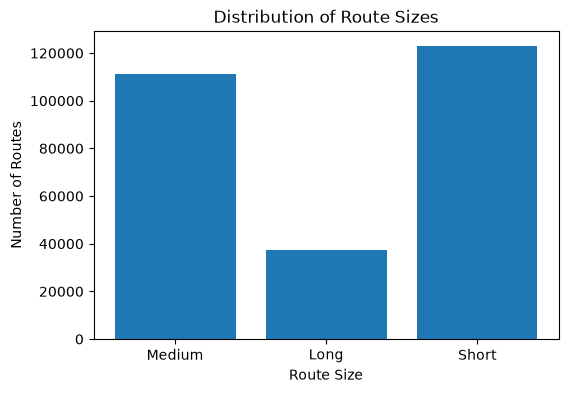

In [11]:
route_counts = df.groupBy("route_size").count().toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(route_counts["route_size"], route_counts["count"])
plt.title("Distribution of Route Sizes")
plt.xlabel("Route Size")
plt.ylabel("Number of Routes")
plt.show()

## Number of Stops Distribution

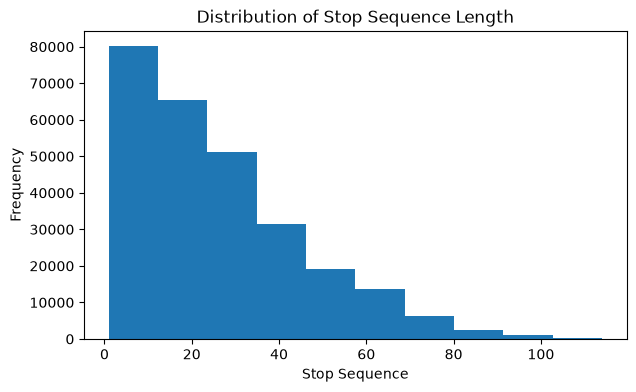

In [12]:
stops = df.select("stop_sequence").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(stops["stop_sequence"], bins=10)

plt.title("Distribution of Stop Sequence Length")
plt.xlabel("Stop Sequence")
plt.ylabel("Frequency")

plt.show()

## Number of Journeys Distribution

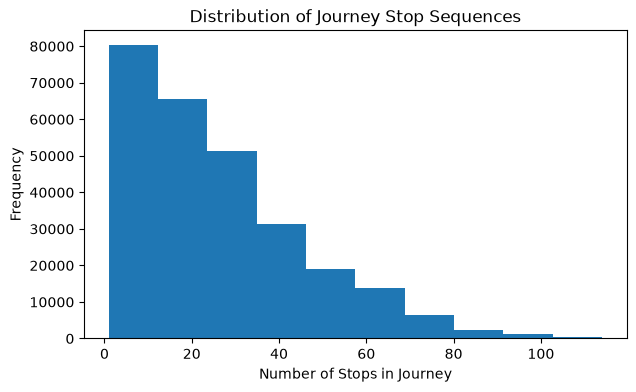

In [13]:
journeys = df.select("stop_sequence").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(journeys["stop_sequence"], bins=10)

plt.title("Distribution of Journey Stop Sequences")
plt.xlabel("Number of Stops in Journey")
plt.ylabel("Frequency")

plt.show()

## Relationship Between Stops and Journeys

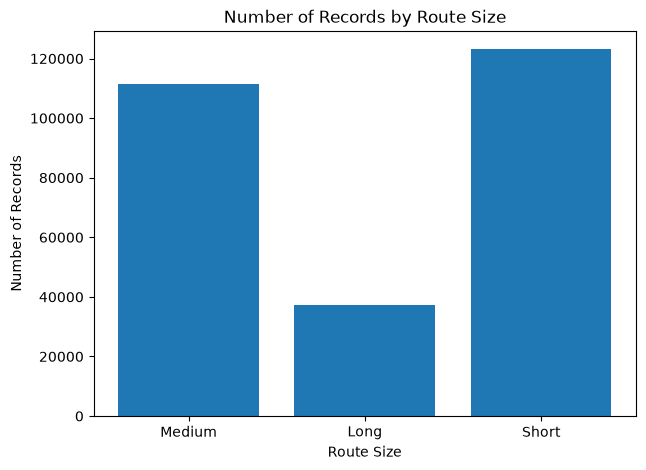

In [15]:
route_df = (
    df.groupBy("route_size")
      .count()
      .toPandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    route_df["route_size"],
    route_df["count"]
)

plt.title("Number of Records by Route Size")
plt.xlabel("Route Size")
plt.ylabel("Number of Records")

plt.show()

# Summary

The exploratory data analysis identified the overall characteristics of the bus timetable dataset. Route sizes, numbers of stops, and journey frequencies were analyzed using summary statistics and visualizations. The analysis showed variations in route lengths and service frequencies, providing useful insights that will support the development of the predictive model in the next stage.